In [2]:
from dataclasses import replace
from functools import partial
from typing import Tuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely.geometry as shap_geom
from shapely.prepared import prep
import sys
sys.path.insert(0, "/mount/moritadbjp/sharefilesjp/work/thickMOTO")

import moto.src.bc as _bc
import moto.src.geometry as _geom
import moto.src.material_points as _mp
import moto.src.mesher as _mesher
import moto.src.mma as _mma
import moto.src.utils as _utils
import moto.src.viz as _viz
from moto.src.hyperelastic_mpm import HyperelasticMPM, StructField
from moto.src.material import StructuralMaterial
from moto.src.nl_solver import LinearSolvers
from moto.src.solve import newton_solve

_Ext = _utils.Extent

jax.config.update("jax_enable_x64", True)
GIF_DIR = "frames"
GIF_PATH = "mpm.gif"
GIF_FPS = 3
frames = []

_Field = StructField

/mount/moritadbjp/sharefilesjp/work/thickMOTO/moto/src/nl_solver.py:22: UserWarning: petsc4py library not found. PETSc solver is not available.
  warnings.warn("petsc4py library not found. PETSc solver is not available.")
/mount/moritadbjp/sharefilesjp/work/thickMOTO/moto/src/nl_solver.py:27: UserWarning: pypardiso library not found. Some solvers may not be available.
  warnings.warn("pypardiso library not found. Some solvers may not be available.")


## Geometry & Mesh

In [4]:
bbox = _geom.BrepGeometry("../brep/rect_domain_expt_1.json")
bar_bbox = _geom.BrepGeometry("../brep/cantilever_expt_1.json")
mesh = _mesher.grid_mesh_brep(
  brep=bbox,
  nelx_desired=80,
  nely_desired=40,
  dofs_per_node=2,
  gauss_order=2,
)

## Material Points Generation 


In [5]:
prepared_beam_geom = prep(bar_bbox.geometry)
inside = np.array(
  [prepared_beam_geom.covers(shap_geom.Point(xy)) for xy in mesh.elem_centers],
  dtype=bool,
)

# Element IDs to populate
occupied_element_ids = np.where(inside)[0]

# MPs
num_mp_per_elem_per_dim = 4
mp_coords = _mesher.generate_mp_coords_in_occupied_elements(
  mesh,
  occupied_element_ids,
  num_mp_per_elem_per_dim,
)
num_mat_pts = mp_coords.shape[0]

# Boundary conditions

In [6]:
face_tol = float(np.asarray(mesh.elem_size)[0]) * 0.5

left_faces = _bc.identify_faces(mesh, edges=[bar_bbox.edges[3]], tol=face_tol)
nL = len(left_faces)

left_clamped = _bc.DirichletBC(
  elem_faces=left_faces,
  values=[(_Field.U, np.zeros(nL)), (_Field.V, np.zeros(nL))],
  name="clamped-left",
)
bcs_list = [left_clamped]
bc = _bc.process_boundary_conditions(bcs_list, mesh)


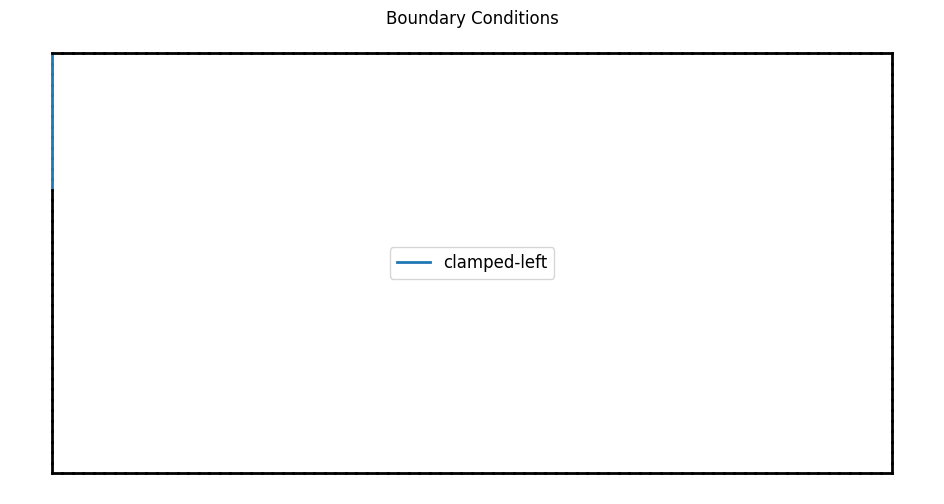

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
_viz.plot_grid_mesh(mesh, ax=ax, colorbar=False)
_viz.plot_bc(bcs_list, mesh, ax=ax)
plt.show()

## Material Initialization

In [8]:
mat = StructuralMaterial(
  youngs_modulus=3.0e9,  # 3.0 GPa
  poissons_ratio=0.4,
  mass_density=1600.0,
  yield_strength=20e4,
)

# MP half-lengths and volumes
thickness = 1e-3
elem_size = jnp.asarray(mesh.elem_size)
half_length_per_mp = elem_size / (2 * num_mp_per_elem_per_dim)
volume_per_mp = (
  thickness * jnp.prod(elem_size) / (num_mp_per_elem_per_dim**mesh.num_dim)
)

max_nodes = 3**mesh.num_dim
max_elems = 2**mesh.num_dim

mp_state, _ = _mp.initialize_new_material_points(
  num_pts=num_mat_pts,
  num_dim=mesh.num_dim,
  max_nodes_per_point=max_nodes,
  max_elems_per_point=max_elems,
)
mass_per_mp = volume_per_mp * mat.mass_density

mp_state = replace(
  mp_state,
  coord=mp_coords,
  volume=volume_per_mp * jnp.ones((num_mat_pts,), dtype=jnp.float64),
  volume0=volume_per_mp * jnp.ones((num_mat_pts,), dtype=jnp.float64),
  mass=mass_per_mp * jnp.ones((num_mat_pts,), dtype=jnp.float64),
  domain_length=jnp.tile(half_length_per_mp[None, :], (num_mat_pts, 1)),
  domain_length0=jnp.tile(half_length_per_mp[None, :], (num_mat_pts, 1)),
)

## Density filter

In [9]:
density_filter = _utils.create_density_filter(
  coords=mp_coords,
  cutoff_distance=1.5 * mesh.elem_size[0],
  filter_type=_utils.Filters.CIRCULAR,
)

#  Forces on material points

In [10]:
# pick loaded material points by bbox
bar_mid = (bar_bbox.geometry.bounds[1] + bar_bbox.geometry.bounds[3]) / 2
bar_right = bar_bbox.geometry.bounds[2]
force_bbox = _mesher.BoundingBox(
  x=_Ext(min=bar_right - face_tol, max=bar_right + face_tol),
  y=_Ext(min=bar_mid - face_tol, max=bar_mid + face_tol),
)

mask = _mesher.compute_point_indices_in_box(np.asarray(mp_state.coord), force_bbox)
loaded_ids = np.where(np.asarray(mask))[0]
if loaded_ids.size == 0:
  raise ValueError(
    "No material points found in force_bbox; widen bbox or check coords."
  )

# distribute a total load across those MPs
F_total = -2.5e2  # total downward force (N)
f_per_mp = F_total / loaded_ids.size

mp_point_force = jnp.zeros((num_mat_pts, mesh.num_dim), dtype=jnp.float64)
mp_point_force = mp_point_force.at[loaded_ids, 1].set(f_per_mp)  # y-dir = 1

mp_state = replace(mp_state, point_force=mp_point_force)
print(f"Applied total force {F_total:.3e} N over {loaded_ids.size} material points.")


Applied total force -2.500e+02 N over 4 material points.


/tmp/ipykernel_2493587/2353907320.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  img = ax.scatter(


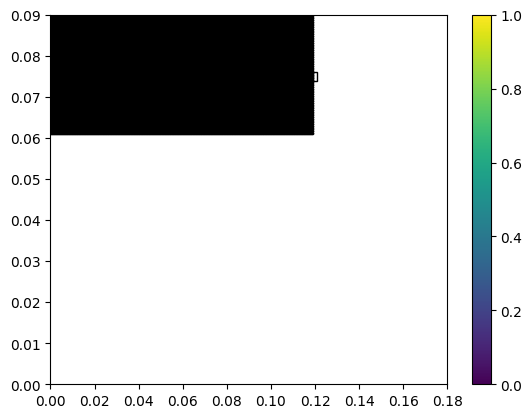

In [11]:
sigma_xy = mp_state.cauchy_stress[:, 3]

fig, ax = plt.subplots()
img = ax.scatter(
  mp_state.coord[:, 0],
  mp_state.coord[:, 1],
  s=2,
  c=sigma_xy,
  cmap="coolwarm",
)

for bbox in [force_bbox]:
  rect = plt.Rectangle(
    (float(bbox.x.min), float(bbox.y.min)),
    float(bbox.x.max - bbox.x.min),
    float(bbox.y.max - bbox.y.min),
    linewidth=1.0,
    edgecolor="black",
    facecolor="None",
  )
  ax.add_patch(rect)

ax.set_xlim([float(mesh.bounding_box.x.min), float(mesh.bounding_box.x.max)])
ax.set_ylim([float(mesh.bounding_box.y.min), float(mesh.bounding_box.y.max)])

plt.colorbar(img, ax=ax)
plt.show()
plt.pause(0.0001)

## Solver Setup

In [12]:
nr_tol, max_nr_iter = 1e-7, 50

solver_settings = {
  "linear": {"solver": LinearSolvers.SCIPY_SPARSE, "rtol": 1e-12},
  "nonlinear": {
    "max_iter": max_nr_iter,
    "threshold": nr_tol,
    "lam_min": 0.01,
    "line_search_max_iter": 12,
    "line_search_shrink": 0.5,
    "line_search_alpha_min": 1e-6,
    "line_search_armijo_c": 1e-4,
  },
}

mpm_problem = HyperelasticMPM(
  solver_settings=solver_settings,
  mesh=mesh,
)

du_guess = jnp.zeros((mesh.num_dofs,)) + 1e-3
du_guess = du_guess.at[bc["fixed_dofs"]].set(0.0)
gravity_vec = jnp.zeros((mesh.num_dim,))


In [13]:
num_load_steps = 15
eta = 0.5
rho_min = 1e-3


In [14]:
def _densities_from_design(
  x: jnp.ndarray,
  penal: float,
  beta: float,
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
  rho_tilde = (density_filter @ x.reshape(-1)).reshape(-1)
  rho_bar = _utils.threshold_filter(rho_tilde, beta=beta, eta=eta)
  rho_bar = jnp.clip(rho_bar, 0.0, 1.0)

  rho_E = rho_min + (1.0 - rho_min) * (rho_bar**penal)

  return rho_bar, rho_E, rho_tilde

In [15]:
@partial(jax.jit, static_argnames=("num_load_steps",))
def objective_function(
  density: jnp.ndarray,
  mp_state0: _mp.MaterialPointConfig,
  penal: float,
  thresh_beta: float,
  num_load_steps: int,
  gravity_vec: jnp.ndarray,
) -> Tuple[jnp.ndarray, jnp.ndarray, _mp.MaterialPointConfig, jnp.ndarray]:
  def obj(x_flat: jnp.ndarray):
    rho_bar, rho_E, _ = _densities_from_design(
      x_flat,
      penal=penal,
      beta=thresh_beta,
    )
    lam = mat.lame_parameters[0] * rho_E
    mu = mat.lame_parameters[1] * rho_E

    matpt_massdens = mat.mass_density * rho_E
    matpt_mass = matpt_massdens * mp_state0.volume0

    mp_state_in = replace(mp_state0, pseudo_density=rho_E, mass=matpt_mass)

    mp_final, _ = newton_solve(
      mesh=mesh,
      mp_state=mp_state_in,
      bc=bc,
      du_guess=du_guess,
      load_steps=num_load_steps,
      gravity=gravity_vec,
      mpm_problem=mpm_problem,
      lame_lambda=lam,
      lame_mu=mu,
      mp_point_force=mp_state_in.point_force,
    )

    obj = jnp.einsum("pd,pd->", mp_state_in.point_force, mp_final.displacement)

    return obj, (mp_final, rho_bar)

  (complaince, (mp_final, rho_bar)), d_complaince = jax.value_and_grad(
    obj, has_aux=True
  )(density.reshape(-1))
  return complaince, d_complaince.reshape((-1, 1)), mp_final, rho_bar


In [16]:
@partial(jax.jit, static_argnames=("max_vol_frac",))
def constraint_function(
  density: jnp.ndarray,
  mp_state0: _mp.MaterialPointConfig,
  max_vol_frac: float,
  penal: float,
  thresh_beta: float,
) -> Tuple[jnp.ndarray, jnp.ndarray]:
  init_vol = mp_state0.volume0.reshape(-1)
  total_init_vol = jnp.sum(init_vol)

  def constraint_wrapper(x_flat: jnp.ndarray) -> jnp.ndarray:
    rho_bar, _, _ = _densities_from_design(
      x_flat,
      penal=penal,
      beta=thresh_beta,
    )
    vol_frac = jnp.sum(rho_bar * init_vol) / total_init_vol
    return (vol_frac / max_vol_frac) - 1.0  # <= 0

  g, dg = jax.value_and_grad(constraint_wrapper)(density.reshape(-1))
  return jnp.array([g]), dg.reshape(1, -1)


## Optimization

In [17]:
def optimize_design(
  mp_state0: _mp.MaterialPointConfig,
  max_vol_frac: float,
  max_iter: int,
  num_load_steps: int = 15,
  gravity_vec=None,
  move_limit: float = 1e-2,
  kkt_tol: float = 1e-7,
  step_tol: float = 1e-7,
  plot_interval: int = 2,
):
  convg_history = {
    "epoch": [],
    "objective": [],
    "volfrac_cons": [],
  }
  if gravity_vec is None:
    gravity_vec = jnp.zeros((mesh.num_dim,), dtype=jnp.float64)

  obj_0 = 1.0
  num_design_var = int(mp_state0.coord.shape[0])

  design_var = (max_vol_frac * np.ones((num_design_var, 1))).astype(np.float64)
  num_cons = 1

  lower_bound = np.zeros((num_design_var, 1))
  upper_bound = np.ones((num_design_var, 1))

  mma_params = _mma.MMAParams(
    max_iter=max_iter,
    kkt_tol=kkt_tol,
    step_tol=step_tol,
    move_limit=move_limit,
    num_design_var=num_design_var,
    num_cons=num_cons,
    lower_bound=lower_bound,
    upper_bound=upper_bound,
  )
  mma_state = _mma.init_mma(design_var, mma_params)

  while mma_state.epoch < max_iter:
    print("mma_state.epoch", mma_state.epoch)

    penal = min(5.0, 1.0 + mma_state.epoch * 0.05)
    thresh_beta = min(32.0, 1.0 + 2.5 * mma_state.epoch)

    objective, grad_obj, mp_final, rho_phys = objective_function(
      mma_state.x, mp_state0, penal, thresh_beta, num_load_steps, gravity_vec
    )

    constr, grad_cons = constraint_function(
      mma_state.x,
      mp_state0,
      max_vol_frac,
      penal=penal,
      thresh_beta=thresh_beta,
    )
    for key, value in zip(
      [
        "epoch",
        "objective",
        "volfrac_cons",
      ],
      [
        mma_state.epoch,
        objective,
        constr[0],
      ],
    ):
      convg_history[key].append(jax.lax.stop_gradient(value))
    status = f"epoch {mma_state.epoch} J {objective:.2E} mc {constr[0]:.2F}"
    print(status)

    if mma_state.epoch == 0 or mma_state.epoch == 10:
      obj_0 = jax.lax.stop_gradient(objective)

    if mma_state.epoch % plot_interval == 0:
      coords = np.asarray(mp_final.coord)
      rho_np = np.asarray(rho_phys)

      fig, ax = plt.subplots()
      img = ax.scatter(coords[:, 0], coords[:, 1], s=2, c=rho_np, cmap="coolwarm")
      ax.set_xlim([float(mesh.bounding_box.x.min), float(mesh.bounding_box.x.max)])
      ax.set_ylim([float(mesh.bounding_box.y.min), float(mesh.bounding_box.y.max)])
      plt.colorbar(img, ax=ax)
      plt.show()
      plt.pause(1e-6)

    mma_state = _mma.update_mma(
      mma_state,
      mma_params,
      objective / obj_0,
      grad_obj / obj_0,
      constr,
      grad_cons,
    )

  return mma_state, mp_final, rho_phys, convg_history


mma_state.epoch 0
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 2.2956000651916267e-09
step 1/1
epoch 0 J 1.04E+01 mc -0.00


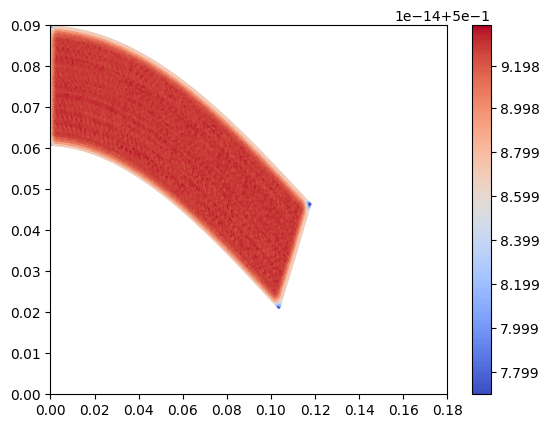

mma_state.epoch 1
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 1.0002711229943994e-08
step 1/1
epoch 1 J 1.07E+01 mc -0.00
mma_state.epoch 2
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 3.949321577511278e-08
step 1/1
epoch 2 J 1.10E+01 mc -0.00


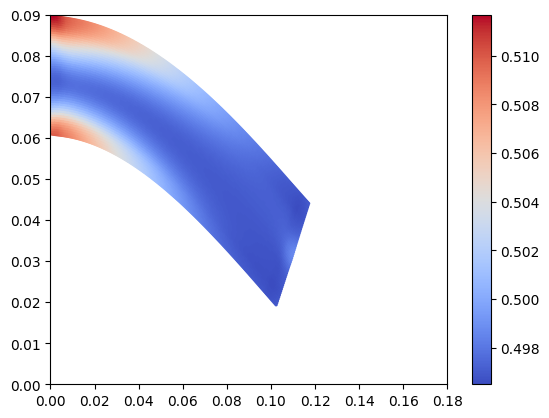

mma_state.epoch 3
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 3.9962824456801165e-08
step 1/1
epoch 3 J 1.11E+01 mc -0.00
mma_state.epoch 4
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 5.6394034374615024e-09
step 1/1
epoch 4 J 1.11E+01 mc -0.01


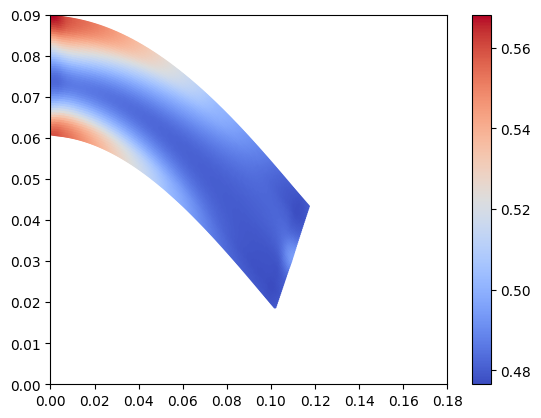

mma_state.epoch 5
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 3.160933711621942e-11
step 1/1
epoch 5 J 1.09E+01 mc -0.01
mma_state.epoch 6
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 1.7504453591575748e-09
step 1/1
epoch 6 J 1.05E+01 mc -0.01


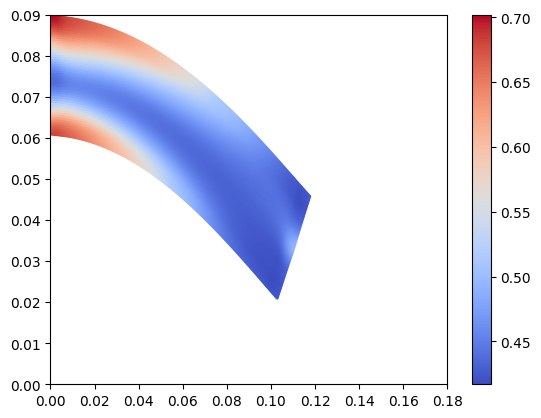

mma_state.epoch 7
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.7228222319072002e-08
step 1/1
epoch 7 J 1.00E+01 mc -0.02
mma_state.epoch 8
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 6.057724211625356e-12
step 1/1
epoch 8 J 9.45E+00 mc -0.02


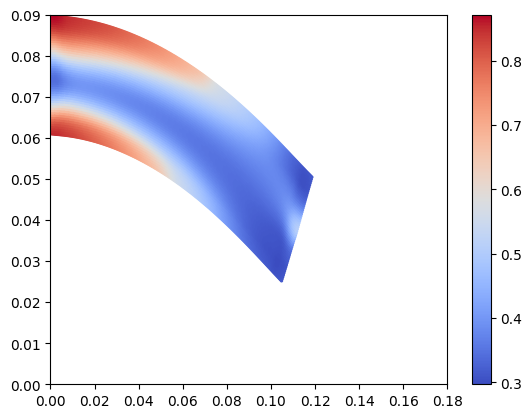

mma_state.epoch 9
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.1295520902776394e-08
step 1/1
epoch 9 J 8.97E+00 mc -0.02
mma_state.epoch 10
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.06946301939494e-10
step 1/1
epoch 10 J 8.63E+00 mc -0.02


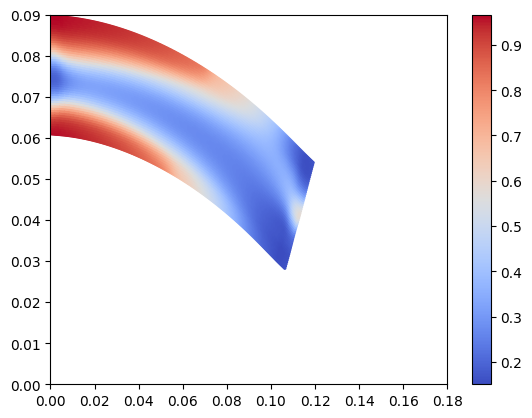

mma_state.epoch 11
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.196944858027958e-11
step 1/1
epoch 11 J 8.45E+00 mc -0.02
mma_state.epoch 12
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.7790560158401764e-11
step 1/1
epoch 12 J 8.37E+00 mc -0.01


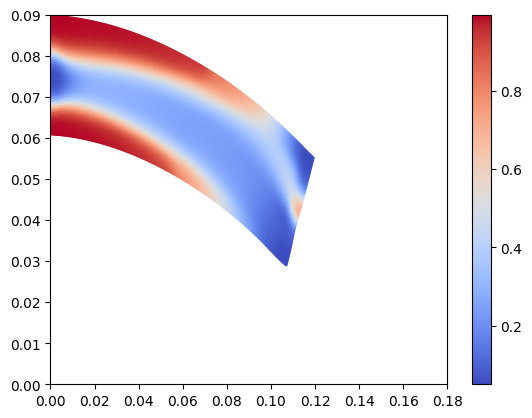

mma_state.epoch 13
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.5066792752902124e-11
step 1/1
epoch 13 J 8.33E+00 mc -0.01
mma_state.epoch 14
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.942763225816881e-11
step 1/1
epoch 14 J 8.33E+00 mc -0.00


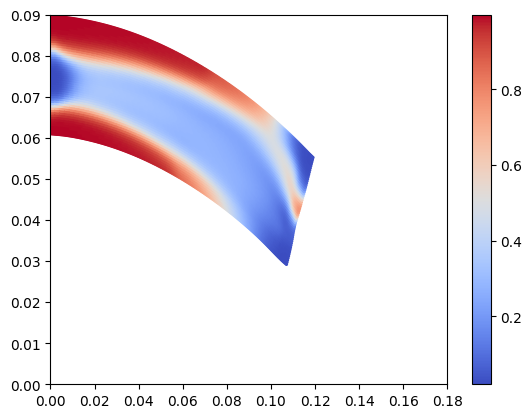

mma_state.epoch 15
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.096251021272352e-11
step 1/1
epoch 15 J 8.36E+00 mc -0.00
mma_state.epoch 16
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.5421949742353495e-10
step 1/1
epoch 16 J 8.40E+00 mc -0.00


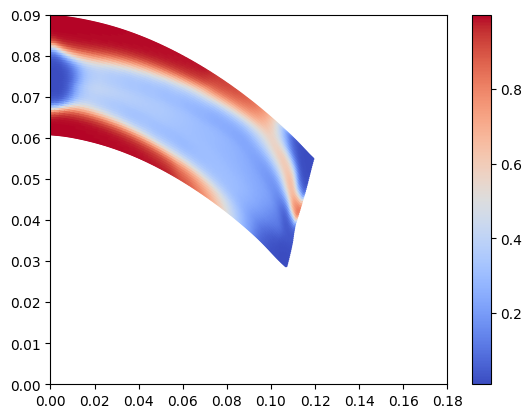

mma_state.epoch 17
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.4282199391340284e-10
step 1/1
epoch 17 J 8.44E+00 mc -0.00
mma_state.epoch 18
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.608591690310448e-10
step 1/1
epoch 18 J 8.48E+00 mc -0.00


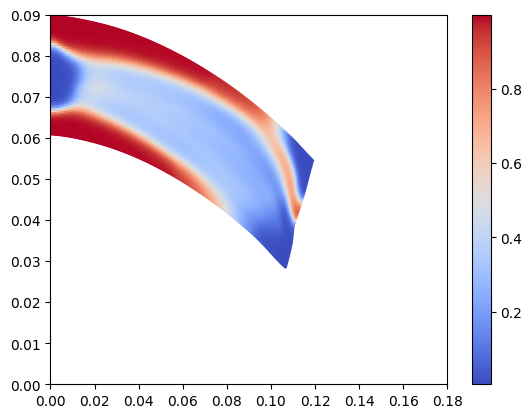

mma_state.epoch 19
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.21394635721979e-09
step 1/1
epoch 19 J 8.52E+00 mc -0.00
mma_state.epoch 20
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.3572000088613515e-09
step 1/1
epoch 20 J 8.55E+00 mc -0.00


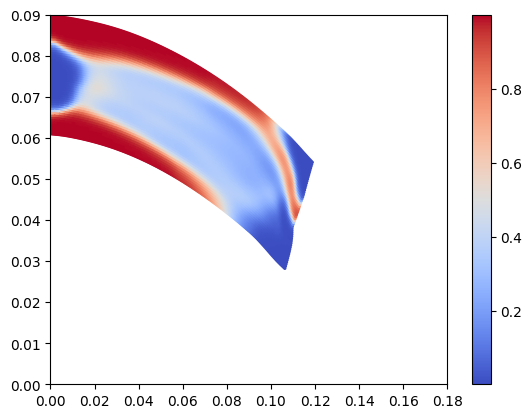

mma_state.epoch 21
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.1805514981393008e-08
step 1/1
epoch 21 J 8.59E+00 mc -0.00
mma_state.epoch 22
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.1532549336532788e-08
step 1/1
epoch 22 J 8.62E+00 mc -0.00


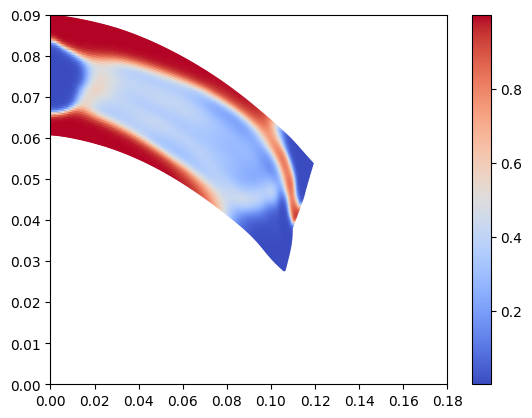

mma_state.epoch 23
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.0845261227631234e-08
step 1/1
epoch 23 J 8.65E+00 mc -0.00
mma_state.epoch 24
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.4869509380611766e-08
step 1/1
epoch 24 J 8.68E+00 mc -0.00


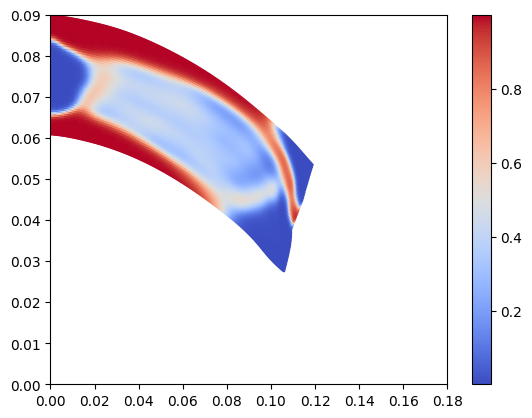

mma_state.epoch 25
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.002466304455137e-08
step 1/1
epoch 25 J 8.70E+00 mc -0.00
mma_state.epoch 26
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.470584003019513e-08
step 1/1
epoch 26 J 8.73E+00 mc -0.00


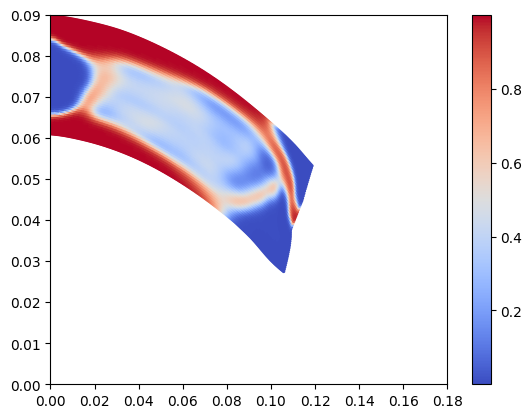

mma_state.epoch 27
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.1899585254370167e-08
step 1/1
epoch 27 J 8.75E+00 mc -0.00
mma_state.epoch 28
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.595513846342124e-08
step 1/1
epoch 28 J 8.77E+00 mc -0.00


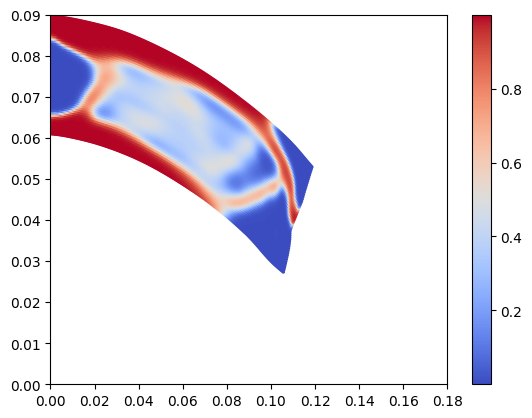

mma_state.epoch 29
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.693130130486049e-11
step 1/1
epoch 29 J 8.80E+00 mc -0.00
mma_state.epoch 30
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.8514542884803824e-08
step 1/1
epoch 30 J 8.82E+00 mc -0.00


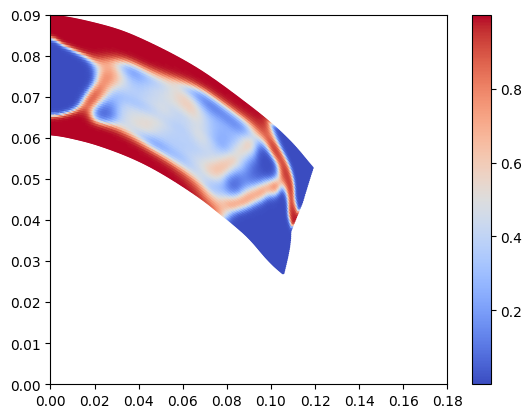

mma_state.epoch 31
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 9.777454918244514e-09
step 1/1
epoch 31 J 8.81E+00 mc -0.00
mma_state.epoch 32
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.684278980730801e-08
step 1/1
epoch 32 J 8.81E+00 mc -0.00


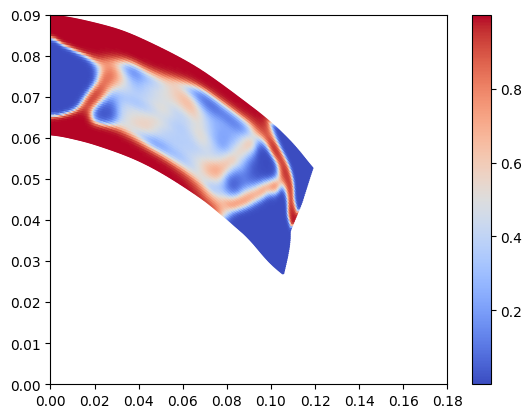

mma_state.epoch 33
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.044001820549692e-08
step 1/1
epoch 33 J 8.81E+00 mc -0.00
mma_state.epoch 34
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.170297407662001e-12
step 1/1
epoch 34 J 8.80E+00 mc -0.00


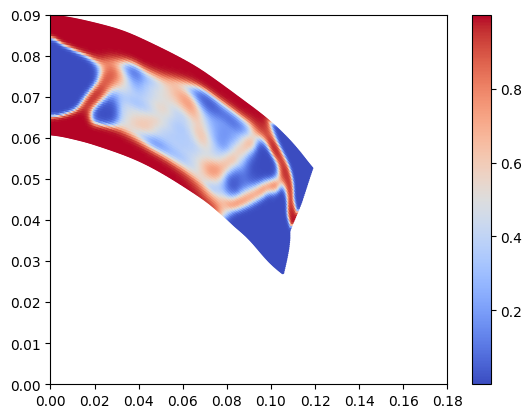

mma_state.epoch 35
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.0724544740505304e-11
step 1/1
epoch 35 J 8.78E+00 mc -0.00
mma_state.epoch 36
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.793752646971198e-09
step 1/1
epoch 36 J 8.75E+00 mc -0.00


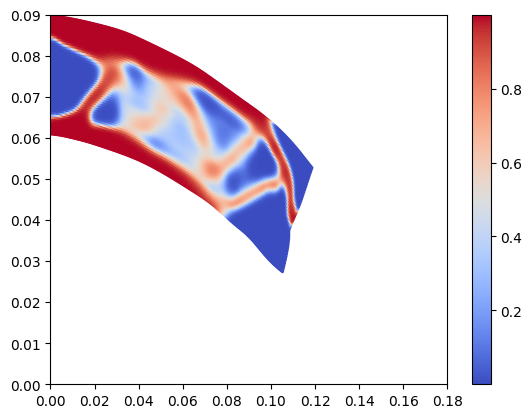

mma_state.epoch 37
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.6384881831986358e-12
step 1/1
epoch 37 J 8.72E+00 mc -0.00
mma_state.epoch 38
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 4.4023182148543805e-10
step 1/1
epoch 38 J 8.69E+00 mc -0.00


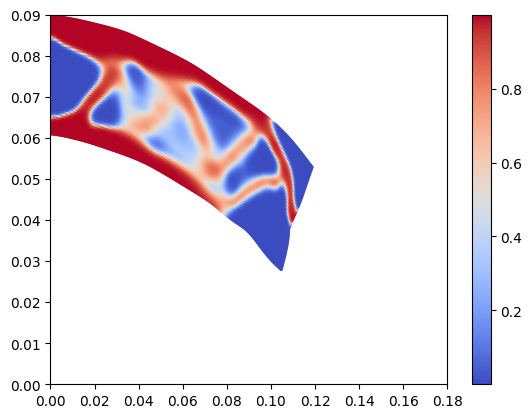

mma_state.epoch 39
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 7.247437640702247e-13
step 1/1
epoch 39 J 8.64E+00 mc -0.00
mma_state.epoch 40
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.723744750300002e-08
step 1/1
epoch 40 J 8.57E+00 mc -0.00


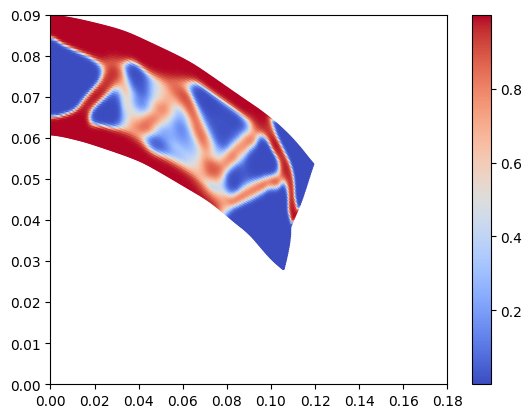

mma_state.epoch 41
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 9.355186496084966e-09
step 1/1
epoch 41 J 8.51E+00 mc -0.00
mma_state.epoch 42
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 4.503304311020052e-12
step 1/1
epoch 42 J 8.44E+00 mc -0.00


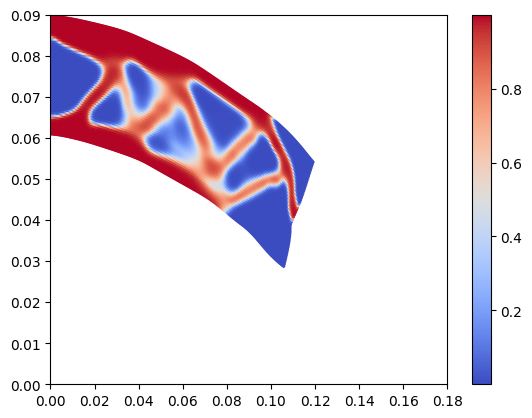

mma_state.epoch 43
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 8.487132669892548e-10
step 1/1
epoch 43 J 8.38E+00 mc -0.00
mma_state.epoch 44
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 9.230990245874121e-08
step 1/1
epoch 44 J 8.31E+00 mc -0.00


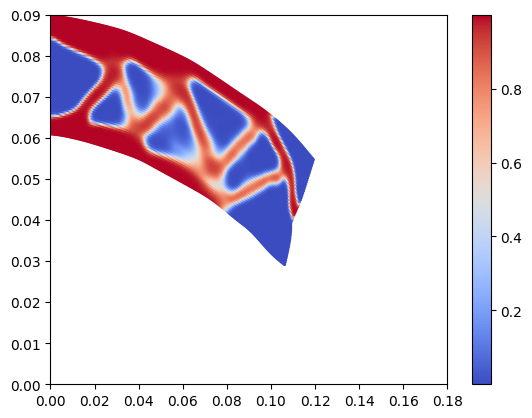

mma_state.epoch 45
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.858281002120975e-09
step 1/1
epoch 45 J 8.26E+00 mc -0.00
mma_state.epoch 46
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 9.248027009758513e-09
step 1/1
epoch 46 J 8.21E+00 mc -0.00


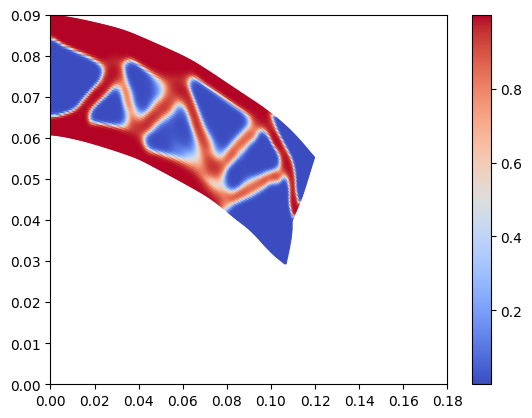

mma_state.epoch 47
step 1/1


In [ ]:
mma_state, mp_final, rho_phys, convg_history = optimize_design(
  mp_state0=mp_state,
  max_vol_frac=0.5,
  max_iter=200,
  move_limit=1e-2,
  num_load_steps=1,
  gravity_vec=gravity_vec,
)

In [ ]:
plt.rcParams.update(_viz.high_res_plot_settings)

coords = np.asarray(mp_coords)
rho_np = np.asarray(rho_phys)

fig, ax = plt.subplots()
img = ax.scatter(coords[:, 0], coords[:, 1], s=2, c=rho_np, cmap=_viz.single_mat_cmap)
ax.set_xlim([float(mesh.bounding_box.x.min), float(mesh.bounding_box.x.max)])
ax.set_ylim([float(mesh.bounding_box.y.min), float(mesh.bounding_box.y.max)])
ax.set_aspect("equal")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
# plt.colorbar(img, ax=ax)
plt.show()